# 따릉이 잔여수량 예측 — 벤치마크 시각화
- 데이터: `results/available_ml_benchmark_results.csv`
- 그림 ①: 모델별 Asym.RMSE 박스플롯
- 그림 ②: 정류소 × 모델 히트맵
- 그림 ③: 모델별 승률 막대
- 그림 ④: Asym.RMSE vs Under-pred 산점도

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── 데이터 로드 ────────────────────────────────────────────────
ROOT_DIR = Path('..').resolve()
df = pd.read_csv(ROOT_DIR / 'results' / 'available_ml_benchmark_results.csv',
                 dtype={'station_id': str})
df = df.drop(columns=["Under-pred rate(%)", "CV-RMSE(%)", "MAPE(%)"])
df["station_id"] = df["station_id"].astype(str).str.zfill(5)


# 컬럼명 통일
ASYM_COL  = [c for c in df.columns if 'Asym' in c][0]
OVER_COL = 'Over-pred rate(%)'
RMSE = 'RMSE'

# 모델 순서 고정
MODEL_ORDER = ['Random Forest',
               'XGBoost', 'XGBoost (alpha=0.5)']
MODEL_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
color_map = dict(zip(MODEL_ORDER, MODEL_COLORS))

df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
df = df.sort_values(['station_id', 'model'])

print(f'Stations: {df["station_id"].nunique()}')
print(f'Models  : {df["model"].nunique()}')
print(f'Records : {len(df)}')
df.head(10)

Stations: 23
Models  : 3
Records : 69


,station_id,model,RMSE,MAE,Asym.RMSE(alpha=0.5),Over-pred rate(%)
0,02111,Random Forest,2.209,1.135,2.053,43.5
1,02111,XGBoost,2.254,1.359,2.063,42.3
2,02111,XGBoost (alpha=0.5),2.230,1.360,1.998,35.1
3,02112,Random Forest,2.059,0.976,1.958,42.9
4,02112,XGBoost,2.160,1.171,2.053,49.4
5,02112,XGBoost (alpha=0.5),2.154,1.192,2.012,42.3
6,02116,Random Forest,0.978,0.678,0.827,50.0
7,02116,XGBoost,0.994,0.733,0.824,43.5
8,02116,XGBoost (alpha=0.5),1.042,0.766,0.817,30.4
9,02122,Random Forest,0.906,0.618,0.752,59.5


## 그림 ① 모델별 Asym.RMSE 박스플롯
> "평일 수요 예측에서 ML이 시계열보다 나은가?"

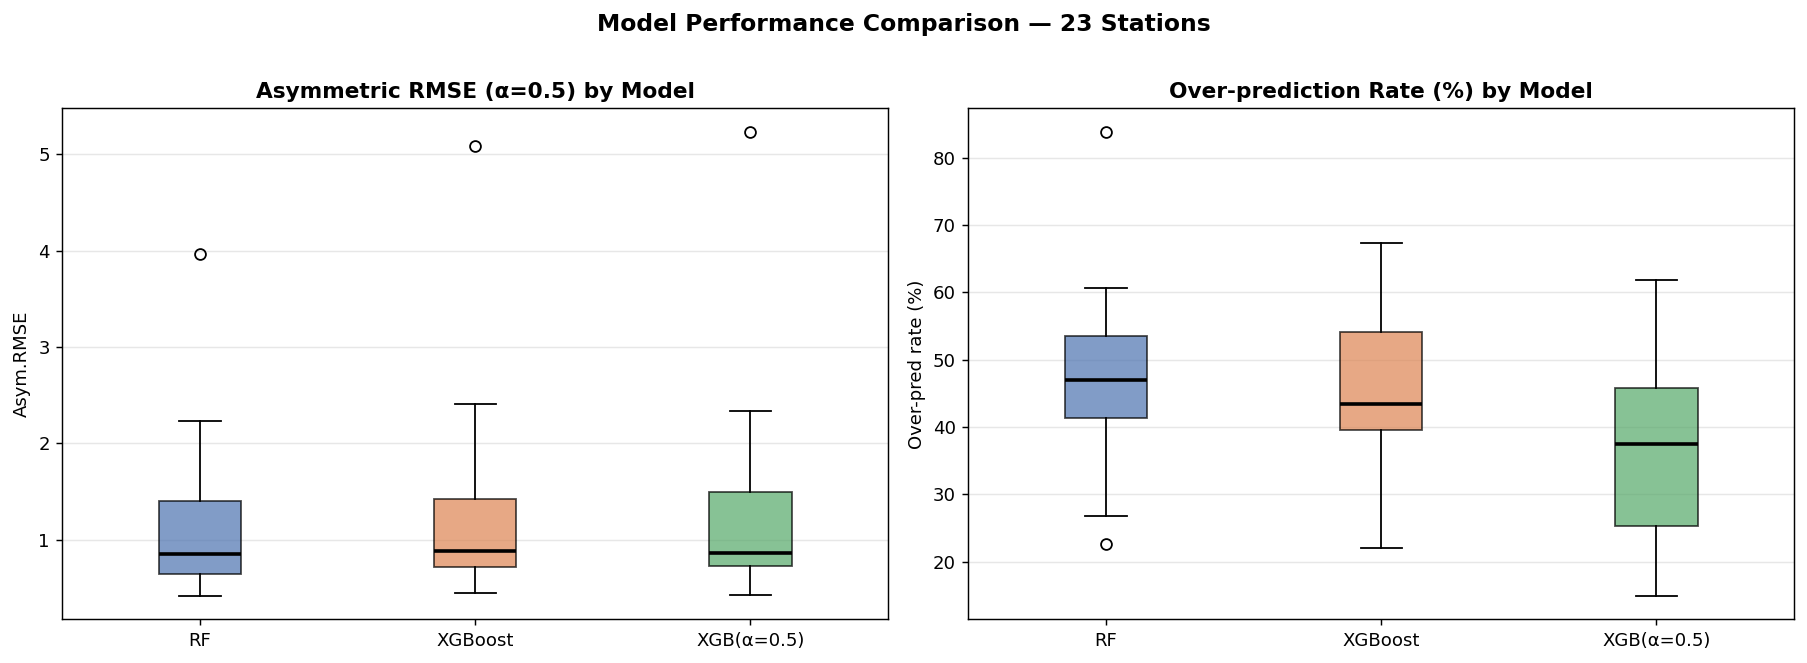

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, ylabel in zip(
    axes,
    [ASYM_COL, OVER_COL],
    ['Asymmetric RMSE (α=0.5) by Model', 'Over-prediction Rate (%) by Model'],
    ['Asym.RMSE', 'Over-pred rate (%)'],
):
    data = [df[df['model'] == m][metric].dropna().values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], MODEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(MODEL_ORDER)+1))
    ax.set_xticklabels(['RF', 'XGBoost', 'XGB(α=0.5)'],
                       fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison — 23 Stations',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT_DIR / 'figures' / 'fig1_boxplot_available.png', bbox_inches='tight')
plt.show()

## 그림 ② 정류소 × 모델 히트맵
> "어느 정류소에서 차이가 크게 나는가?"

/var/folders/pw/tlmw7mpd0lg2r9m2x779s9940000gn/T/ipykernel_78263/4011979180.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='station_id', columns='model',


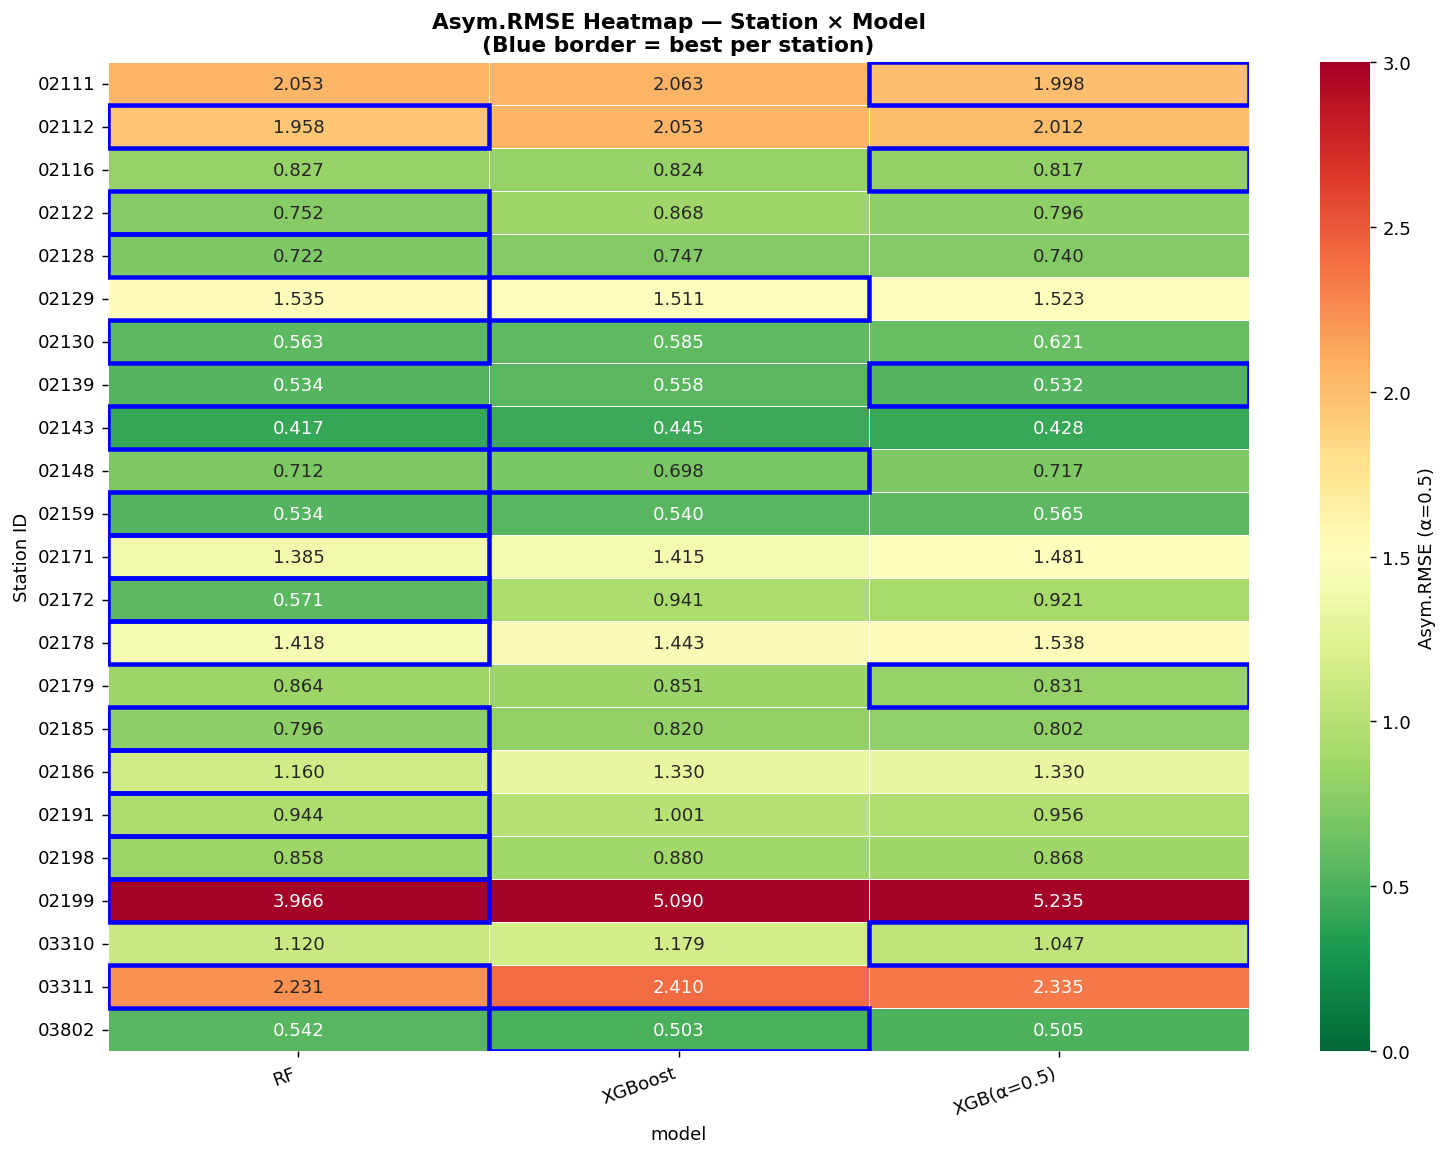

In [38]:
# 피벗
pivot = df.pivot_table(index='station_id', columns='model',
                       values=ASYM_COL, aggfunc='mean')
pivot = pivot[MODEL_ORDER]

# 정류소별 best 모델 마스크
best_mask = pivot.eq(pivot.min(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=3,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Asym.RMSE (α=0.5)"}
)

# best 칸에 테두리
for i, station in enumerate(pivot.index):
    for j, model in enumerate(pivot.columns):
        if best_mask.loc[station, model]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1,
                         fill=False, edgecolor='blue', linewidth=2.5))

ax.set_xticklabels(['RF', 'XGBoost', 'XGB(α=0.5)'],
                   rotation=20, ha='right')
ax.set_ylabel('Station ID')
ax.set_title('Asym.RMSE Heatmap — Station × Model\n(Blue border = best per station)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT_DIR / 'figures' / 'fig2_heatmap_available.png', bbox_inches='tight')
plt.show()

## 그림 ③ 모델별 승률 막대
> "몇 개 정류소에서 각 모델이 최선이었나?"

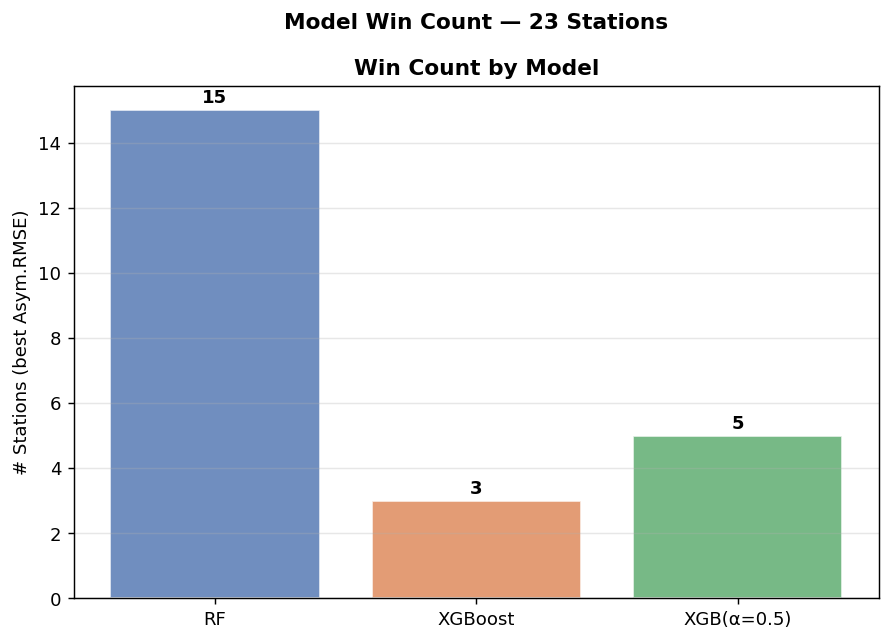


[승률 요약]
Random Forest          15
XGBoost                 3
XGBoost (alpha=0.5)     5


In [39]:
# 정류소별 best 모델
best_model = pivot.idxmin(axis=1)
win_counts = best_model.value_counts().reindex(MODEL_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    range(len(MODEL_ORDER)),
    win_counts.values,
    color=MODEL_COLORS,
    alpha=0.8,
    edgecolor="white"
)

ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(
    ['RF', 'XGBoost', 'XGB(α=0.5)'],
    fontsize=10
)

ax.set_ylabel('# Stations (best Asym.RMSE)')
ax.set_title(
    'Model Win Count — 23 Stations\n\nWin Count by Model',
    fontsize=12,
    fontweight='bold'
)

for bar, val in zip(bars, win_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        str(val),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0.08, 0.08, 0.95, 0.92])
plt.savefig(
    ROOT_DIR / 'figures' / 'fig3_winrate_available.png',
    bbox_inches='tight'
)
plt.show()

print('\n[승률 요약]')
print(win_counts.to_string())

## 그림 ④ RMSE vs Under-pred 산점도
> "정확도는 좋은데 고갈 위험만 높은 모델은?"

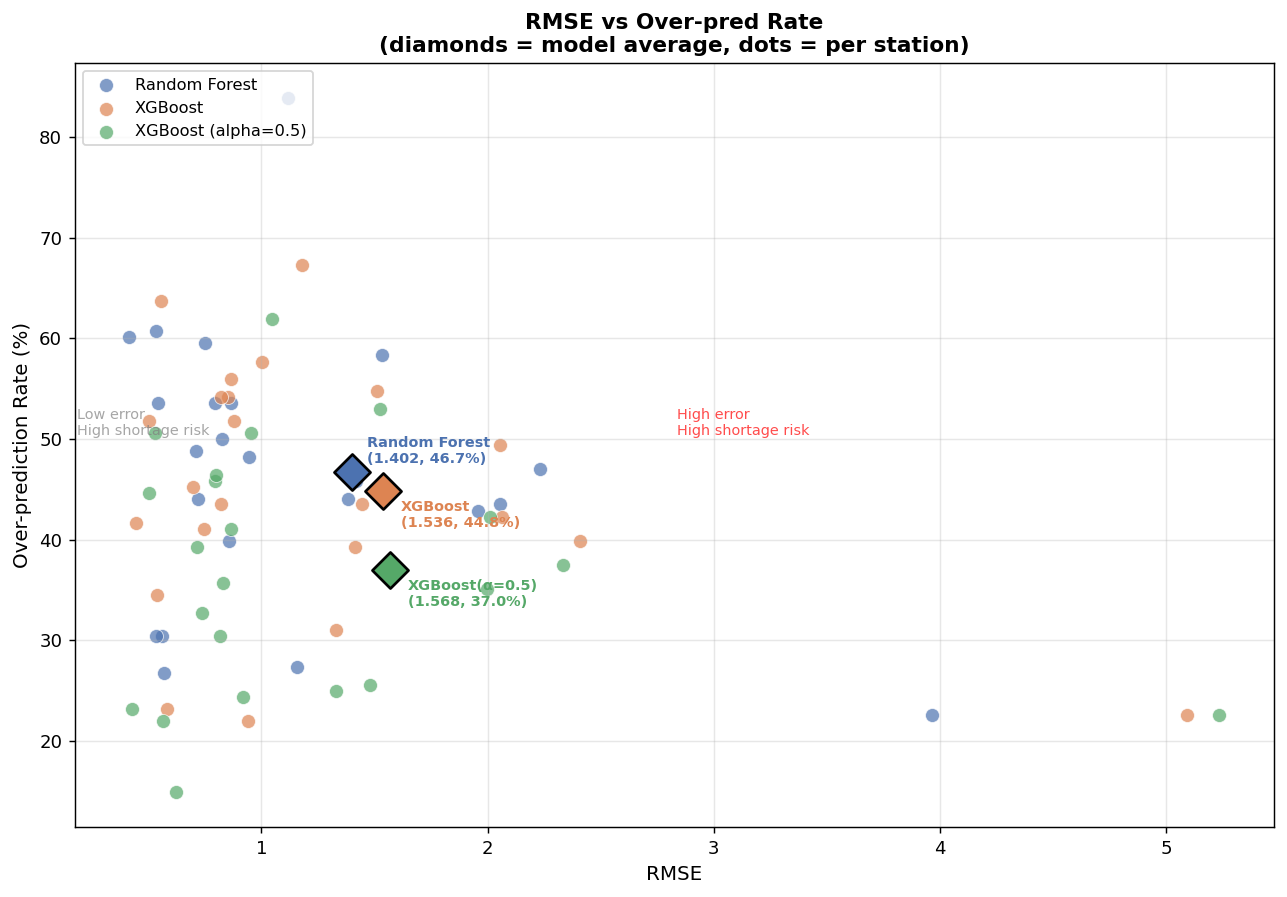

In [40]:
fig, ax = plt.subplots(figsize=(10, 7))

for model, color in color_map.items():
    sub = df[df['model'] == model]
    ax.scatter(sub[ASYM_COL], sub[OVER_COL],
               color=color, alpha=0.7, s=60, label=model, edgecolors='white', linewidth=0.5)

# 모델별 평균 표시
for model, color in color_map.items():
    sub = df[df['model'] == model]
    mx, my = sub[RMSE].mean(), sub[OVER_COL].mean()

    ax.scatter(
        mx, my,
        color=color,
        s=200,
        marker='D',
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )

    label = model.replace(' (temp+rain)', '').replace(' (alpha=0.5)', '(α=0.5)')

    if model == 'Random Forest':
        xytext = (8, 5)
    else:
        xytext = (10, -20) 

    ax.annotate(
        f'{label}\n({mx:.3f}, {my:.1f}%)',
        (mx, my),
        textcoords='offset points',
        xytext=xytext,
        fontsize=8,
        color=color,
        fontweight='bold'
    )

ax.set_xlabel('RMSE', fontsize=11)
ax.set_ylabel('Over-prediction Rate (%)', fontsize=11)
ax.set_title('RMSE vs Over-pred Rate\n(diamonds = model average, dots = per station)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# 사분면 라벨
xlim, ylim = ax.get_xlim(), ax.get_ylim()
xmid = (xlim[0] + xlim[1]) / 2
ymid = (ylim[0] + ylim[1]) / 2
ax.text(xlim[0]+0.01, ymid+1, 'Low error\nHigh shortage risk', fontsize=8,
        color='gray', alpha=0.7)
ax.text(xmid+0.01, ymid+1, 'High error\nHigh shortage risk', fontsize=8,
        color='red', alpha=0.7)

plt.tight_layout()
plt.savefig(ROOT_DIR / 'figures' / 'fig4_scatter_available.png', bbox_inches='tight')
plt.show()

## 요약 통계

In [41]:
summary = df.groupby('model')[[ASYM_COL, OVER_COL, 'RMSE', 'MAE']].agg(
    ['mean', 'std']
).round(3)
print('\n[모델별 평균 성능 (23개 정류소)]')
print(summary.to_string())


[모델별 평균 성능 (23개 정류소)]
                    Asym.RMSE(alpha=0.5)        Over-pred rate(%)           RMSE           MAE       
                                    mean    std              mean     std   mean    std   mean    std
model                                                                                                
Random Forest                      1.151  0.802            46.739  13.793  1.402  1.075  0.886  0.872
XGBoost                            1.250  0.993            44.813  12.458  1.536  1.368  1.052  1.155
XGBoost (alpha=0.5)                1.243  1.016            36.978  12.077  1.568  1.397  1.086  1.186


/var/folders/pw/tlmw7mpd0lg2r9m2x779s9940000gn/T/ipykernel_78263/451345552.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('model')[[ASYM_COL, OVER_COL, 'RMSE', 'MAE']].agg(
